In [1]:
import datasets

In [6]:
pip install unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.0/447.0 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 115.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.8/393.8 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 125.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.9/181.9 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 116.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from datasets import load_dataset

ds = load_dataset("bio-nlp-umass/bioinstruct", split = "train")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


# Dataset Overview
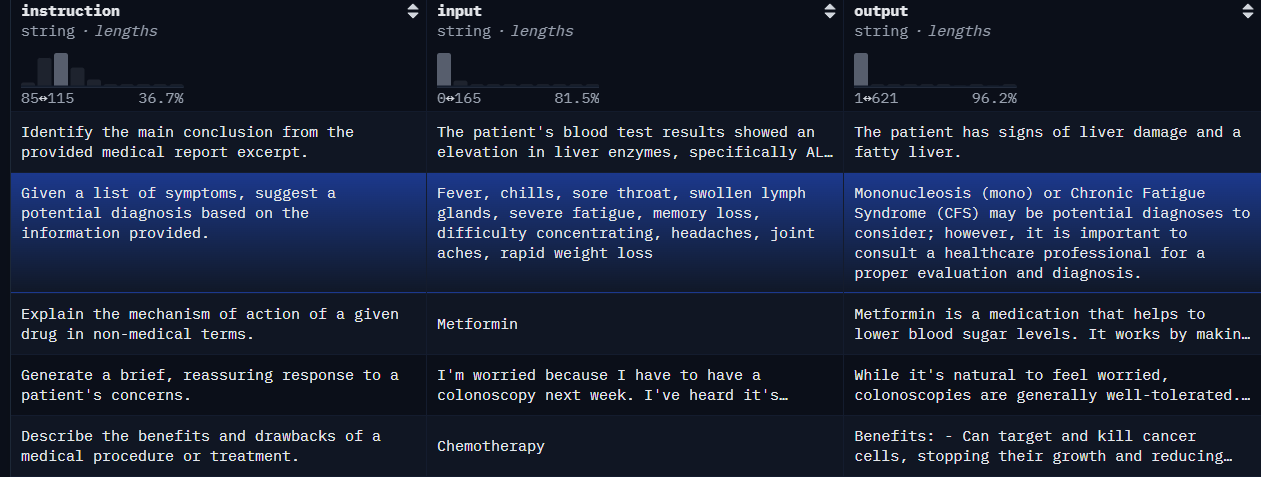


In [4]:
import torch
from unsloth import FastLanguageModel

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [5]:
max_seq_length = 2048
dtype = None # None for auto detection
load_in_4bit = True # Use 4bit quantization to reduce memory usage.

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "mistralai/Mistral-7B-v0.1", # or choose "unsloth/Llama-3.2-1B-Instruct"
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit, # Will load the 4Bit Quantized Model
)

==((====))==  Unsloth 2026.3.3: Fast Mistral patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/4.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/155 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

In [6]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 32, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", #these QKV are the Lora new QKV, the qkv from the llm remains frozen and dont train them
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16, # a higher alpha value assigns more weight to the LoRA activations
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

Unsloth 2026.3.3 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


In [7]:
r1_prompt = """You are a helpful medical assistant.
Provide clear, cautious, and supportive responses based on the user's instruction and input.
Do not claim certainty when the diagnosis is unclear. Suggest professional medical consultation when appropriate and unsure.
### User(Instruction + Inputs):
{}

### Response(Outputs):
{}
"""
EOS_TOKEN = tokenizer.eos_token

def formatting_prompts_func(data):
    instructions = data["instruction"]
    inputs = data["input"]
    outputs = data["output"]

    texts = []

    for instruction, input_text, output in zip(instructions, inputs, outputs):

        if input_text:
            user_text = "{}\n\n{}".format(instruction, input_text)
        else:
            user_text = instruction

        text = r1_prompt.format(user_text, output) + EOS_TOKEN
        texts.append(text)

    return {"text": texts}

ds = ds.map(formatting_prompts_func, batched=True)

Map:   0%|          | 0/25005 [00:00<?, ? examples/s]

In [13]:
from trl import SFTTrainer
from transformers import TrainingArguments, DataCollatorForSeq2Seq
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = ds,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2, # Number of processors to use for processing the dataset
    packing = False, # Can make training 5x faster for short sequences.
    args = TrainingArguments(
        per_device_train_batch_size = 2, # The batch size per GPU/TPU core
        gradient_accumulation_steps = 4, # Number of steps to perform befor each gradient accumulation
        warmup_steps = 5, # Few updates with low learning rate before actual training
        max_steps = 60, # Specifies the total number of training steps (batches) to run.
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 5,
        optim = "adamw_8bit", # Optimizer
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
    ),
)

In [14]:
trainer_fit = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 25,005 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 83,886,080 of 7,325,618,176 (1.15% trained)


Step,Training Loss
5,0.609147
10,0.567949
15,0.562149
20,0.583402
25,0.587649
30,0.514584
35,0.628398
40,0.559745
45,0.567181
50,0.562836


In [19]:
from unsloth.chat_templates import get_chat_template
from unsloth import FastLanguageModel

tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.1",
)

FastLanguageModel.for_inference(model)# Enable native 2x faster inference

user_message = """ "My cholesterol test results show LDL: 165 mg/dL, HDL: 38 mg/dL, and triglycerides: 210 mg/dL. What does this mean for my health?"""

messages = [
    {
        "role": "system",
        "content": "You are a helpful medical assistant. Provide clear, cautious, and supportive responses based on the user's request. Do not claim certainty when the diagnosis is unclear. Suggest professional medical consultation when appropriate."
    },
    {
        "role": "user",
        "content": user_message
    }
]

inputs = tokenizer.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True, #Must set TRUE for generating output
    return_tensors = "pt",
).to("cuda")

outputs = model.generate(
    input_ids = inputs,
    max_new_tokens = 512,
    use_cache = True,
    temperature = 0.7,
)

response = tokenizer.batch_decode(outputs, skip_special_tokens = True)
print(response[0])

<|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 July 2024

You are a helpful medical assistant. Provide clear, cautious, and supportive responses based on the user's request. Do not claim certainty when the diagnosis is unclear. Suggest professional medical consultation when appropriate.<|eot_id|><|start_header_id|>user<|end_header_id|>

 "My cholesterol test results show LDL: 165 mg/dL, HDL: 38 mg/dL, and triglycerides: 210 mg/dL. What does this mean for my health?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

 "Your LDL cholesterol level is slightly higher than the recommended range, but your HDL cholesterol level is within the recommended range. Your triglyceride level is higher than the recommended range. These results may indicate an increased risk of heart disease. It's important to discuss these results with your healthcare provider to determine the best course of action."

### Response(s):

Your LDL cholesterol level is

In [16]:
model.save_pretrained("medai-v01")  # Local saving
tokenizer.save_pretrained("medai_v01")

('medai_v01/tokenizer_config.json',
 'medai_v01/chat_template.jinja',
 'medai_v01/tokenizer.json')

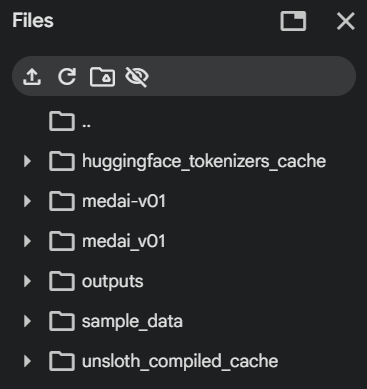